#Librerías


In [ ]:
!pip install category_encoders


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import hashlib
import requests
import io
from scipy.stats import chi2_contingency
import itertools
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from category_encoders import TargetEncoder



#Carga del dataset

In [ ]:
url = "https://raw.githubusercontent.com/Mapabaoy12/EncargoMachineLearning1/refs/heads/main/dataset/Spotify_Tracks_Dataset.csv"
HASH_ORIGINAL = "b202fa49909b2d5cef71a04b1d21243cfeb36414535f2ca9272aa646721177bd"


In [ ]:
try:
    # intento de descarga y validación
    response = requests.get(url)
    response.raise_for_status()  # verifica que url funcione y no de error

    contenido_raw = response.content
    hash_calculado = hashlib.sha256(contenido_raw).hexdigest()

    if hash_calculado == HASH_ORIGINAL:
        print("AUDITORÍA EXITOSA: Integridad de procedencia garantizada.")
        df = pd.read_csv(io.BytesIO(contenido_raw))
        print("Dataset cargado correctamente.")
    else:
        # si hash no coincide, da un error manual
        raise ValueError("El hash no coincide. El archivo ha sido modificado o está corrupto.")

except Exception as e:
    # captura cualquier error y detiene el proceso
    raise RuntimeError(f"FALLO CRÍTICO: No se pudo procesar el dataset. Detalle: {e}")

AUDITORÍA EXITOSA: Integridad de procedencia garantizada.
Dataset cargado correctamente.


#Análisis exploratorio de los datos

El listado de variables que forman parte del dataset es el siguiente:

"track_id": Identificador de Spotify para la canción

"artists": Artista de la canción, si hay más de uno se separa con ;

"album_name": Álbum donde la canción aparece

"track_name": Nombre de la pista de audio musical

"popularity": Popularidad de la canción bajo una puntuación de 0 a 100

"duration_ms": Duración en segundos

"explicit": Contenido explícito de la canción (letras), variable False o True

"danceability": Escala que denomina qué tan bailable es una canción de 0.0 a 1.0

"energy": Intensidad de la canción medida en 0.0 a 1.0

"key": Tonalidad / escala de notas de la canción, del 0 al 11

"loudness": Sonoridad de la canción medida en decibeles

"mode": Escala melódica de la canción

"speechiness": Cantidad de palabras en escala de 0.0 a 1.0

"acousticness": Escala de 0.0 a 1.0 para medir si una canción es acústica

"instrumentalness": Escala de 0.0 a 1.0 para medir si una canción es más instrumental

"liveness": Escala de 0.0 a 1.0 para medir si la canción fue cantada en live

"valence": Positividad medida en 0.0 a 1.0

"tempo": Tempo estimado de la canción

"time_signature": Cantidad de beats en una canción

"track_genre": Género de la canción

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
#fila(s) con valores nulos
filas_con_nulos = df[df.isna().any(axis=1)]
filas_con_nulos

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [ ]:
# eliminar track_id 1kR4gIb7nGxHPI3D2ifs59 del df ya que es el único nulo
df.drop(df[df['track_id'] == '1kR4gIb7nGxHPI3D2ifs59'].index, inplace=True)

In [ ]:
# Se descarta la columna "Unnamed: 0" del dataset por la nula relevancia predictiva
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
# Conversión de milisegundos a segundos y renombramiento

df["duration_ms"] = df["duration_ms"] / 1000
df.rename(columns={"duration_ms": "duration_s"}, inplace=True)

In [ ]:
# Cantidad total de géneros únicos (excluyendo nulos por defecto)
total_generos = df['track_genre'].nunique()
print(f"Total de géneros únicos: {total_generos}")

Total de géneros únicos: 114


In [ ]:
# duplicados de df track_id
duplicados_id = df[df.duplicated(subset=['track_id'], keep=False)].sort_values(by='track_id')
duplicados_id.head()

,track_id,artists,album_name,track_name,popularity,duration_s,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
15028,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176.320,False,0.613,0.471,1,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,chill
103211,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176.320,False,0.613,0.471,1,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,soul
85578,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177.266,False,0.554,0.921,2,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,punk-rock
100420,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177.266,False,0.554,0.921,2,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,ska
91801,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222.973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,rock


In [ ]:
# buscar duplicado considerando track_id y track_genre
duplicados_id = df[df.duplicated(subset=['track_id', 'track_genre'], keep=False)].sort_values(by='track_id')
duplicados_id.shape

(894, 20)

In [ ]:
#Eliminación de duplicados que tengan el "track_id" y "track_genre" igual
df.drop_duplicates(subset=['track_id', 'track_genre'], inplace=True)


In [ ]:
# correlación de variables numéricas con respecto a "popularity"
df.select_dtypes(include=['number']).corrwith(df['popularity'],method='spearman').sort_values(ascending=False)

,0
popularity,1.000000
time_signature,0.035834
loudness,0.033146
duration_s,0.026528
danceability,0.025760
tempo,0.015990
acousticness,0.011263
key,-0.002860
liveness,-0.008356
mode,-0.015554


In [ ]:
# mezclas de 2 variables y hacer correlación con popularity para hacer descubrimientos
# 6 variables con >3% de correlación original
top_vars = [
    "loudness", "danceability", "time_signature",
    "valence", "speechiness", "instrumentalness"
]

target = "popularity"
resultados = []
dfprueba = df.copy()
# Generar todas las combinaciones posibles de a 2 variables
for var1, var2 in itertools.combinations(top_vars, 2):

    # 1. Multiplicación (Efecto de interacción conjunta)
    dfprueba[f"{var1}_x_{var2}"] = dfprueba[var1] * dfprueba[var2]
    corr_mult = dfprueba[f"{var1}_x_{var2}"].corr(dfprueba[target])
    resultados.append({"Variables": f"{var1} y {var2}", "Operacion": "Multiplicación", "Correlacion": corr_mult})

    # 2. Suma (Efecto aditivo)
    dfprueba[f"{var1}_+_{var2}"] = dfprueba[var1] + dfprueba[var2]
    corr_suma = dfprueba[f"{var1}_+_{var2}"].corr(dfprueba[target])
    resultados.append({"Variables": f"{var1} y {var2}", "Operacion": "Suma", "Correlacion": corr_suma})

    # 3. Ratio (Proporción). Se suma un valor ínfimo (1e-5) para evitar división por cero
    dfprueba[f"{var1}_ratio_{var2}"] = dfprueba[var1] / (dfprueba[var2] + 1e-5)
    corr_ratio = dfprueba[f"{var1}_ratio_{var2}"].corr(dfprueba[target])
    resultados.append({"Variables": f"{var1} y {var2}", "Operacion": "Ratio", "Correlacion": corr_ratio})

# Convertir a DataFrame y ordenar por el valor absoluto de la correlación
df_resultados = pd.DataFrame(resultados)
df_resultados['Correlacion_Abs'] = df_resultados['Correlacion'].abs()
df_resultados = df_resultados.sort_values(by='Correlacion_Abs', ascending=False).drop(columns=['Correlacion_Abs'])

# Ver el Top 5 de mejores combinaciones
print(df_resultados.head())

                            Variables       Operacion  Correlacion
40         valence y instrumentalness            Suma    -0.119983
43     speechiness y instrumentalness            Suma    -0.107306
39         valence y instrumentalness  Multiplicación    -0.096336
42     speechiness y instrumentalness  Multiplicación    -0.094644
33  time_signature y instrumentalness  Multiplicación    -0.094207


Tras evaluar las variables cuantitativas originales e implementar técnicas de ingeniería de características mediante combinaciones aditivas, multiplicativas y de ratios sobre los atributos de mayor correlación, se constató que la asociación lineal máxima alcanzada no supera un coeficiente de Pearson de $\vert{}r\vert{} = 0.12$. De acuerdo con los criterios estándar de evaluación estadística, magnitudes inferiores a $0.30$ reflejan una relación débil a despreciable, explicando menos del $1.5\%$ de la varianza del objetivo. Se concluye que las variables numéricas disponibles carecen de la señal predictiva necesaria para estimar la popularidad de manera confiable. Por consiguiente, se justifica descartar estos atributos como predictores cuantitativos directos en los modelos lineales de regresión, priorizando la capacidad explicativa de variables categóricas o requiriendo la integración de fuentes de datos orientadas al alcance comercial del artista.

In [ ]:
# 1. Erradicar los duplicados exactos (Limpieza base)
df = df.drop_duplicates().copy()

# 2. Consolidar multietiqueta y extraer el "Género Principal"
# Al usar .first(), si una canción tiene filas repetidas con "rock" e "indie",
# colapsa a 1 sola fila conservando únicamente "rock".
df = df.groupby('track_id', as_index=False).first()

# 3. Calcular frecuencias reales (SOBRE EL DATASET YA DESDUPLICADO)
frecuencias = df['track_genre'].value_counts(normalize=True)

# 4. Identificar géneros con MÁS del 0.75% de representación
generos_top = frecuencias[frecuencias > 0.0075].index.tolist()

# 5. Reemplazar géneros del 0.75% o menos por la categoría 'otros'
df['track_genre'] = df['track_genre'].apply(
    lambda x: x if x in generos_top else 'otros'
)

# --- Verificación de Resultados ---
print(f"Total de canciones únicas: {df.shape[0]}")
print(f"Cantidad de géneros finales: {df['track_genre'].nunique()}")
print("\nTop 5 géneros resultantes (en %):")
print(round(df['track_genre'].value_counts(normalize=True) * 100, 2).head())

Total de canciones únicas: 89740
Cantidad de géneros finales: 88

Top 5 géneros resultantes (en %):
track_genre
otros       12.78
acoustic     1.11
afrobeat     1.11
alt-rock     1.11
tango        1.11
Name: proportion, dtype: float64


In [ ]:
#Verificacion de generos que se guardaron despues de la limpieza.
#Aseguramos que no existan errores de formato
df["track_genre"].unique()

array(['german', 'club', 'minimal-techno', 'hip-hop', 'comedy', 'chill',
       'otros', 'bluegrass', 'happy', 'drum-and-bass', 'idm', 'alt-rock',
       'emo', 'honky-tonk', 'industrial', 'j-dance', 'grindcore',
       'french', 'world-music', 'hard-rock', 'forro', 'j-pop', 'indian',
       'children', 'power-pop', 'pagode', 'blues', 'romance', 'study',
       'afrobeat', 'black-metal', 'grunge', 'opera', 'show-tunes',
       'heavy-metal', 'k-pop', 'progressive-house', 'acoustic', 'anime',
       'ambient', 'iranian', 'synth-pop', 'chicago-house', 'kids',
       'disco', 'pop-film', 'mandopop', 'swedish', 'tango', 'funk',
       'latin', 'piano', 'spanish', 'turkish', 'salsa', 'electronic',
       'goth', 'dance', 'malay', 'death-metal', 'trance', 'country',
       'hardstyle', 'folk', 'mpb', 'disney', 'j-idol', 'hardcore',
       'british', 'guitar', 'dub', 'deep-house', 'brazil', 'metalcore',
       'dancehall', 'trip-hop', 'party', 'breakbeat', 'sleep',
       'detroit-techno', 'g

In [ ]:
#Agrupamos el dataset por identificador unico, aplicando .first()
#para conservar unicamente la primera aparicion
df = df.groupby('track_id', as_index=False).first()

#Feature engineering

In [ ]:
# ==============================================================================
# INGENIERÍA DE CARACTERÍSTICAS: INTERACCIÓN ACÚSTICA ADITIVA
# ==============================================================================
# Se combinan 'valence' (valencia emocional, escala 0 a 1) e 'instrumentalness'
# (presencia instrumental, escala 0 a 1) mediante suma aritmética.
# Individualmente presentan correlaciones lineales bajas con 'popularity' (4% y 9%),
# pero su combinación aditiva eleva la fuerza de asociación conjunta al 12%.

df['valence_instrumentalness_sum'] = df['valence'] + df['instrumentalness']

# Verificación de rango y cálculo de correlaciones
print(f"Rango de nueva variable: [{df['valence_instrumentalness_sum'].min():.2f}, {df['valence_instrumentalness_sum'].max():.2f}]")
print(f"Correlación con popularity: {df['valence_instrumentalness_sum'].corr(df['popularity']):.4f}")
print(f"Correlación de speechiness con popularity: {df['speechiness'].corr(df['popularity']):.4f}")

Rango de nueva variable: [0.00, 1.95]
Correlación con popularity: -0.1292
Correlación de speechiness con popularity: -0.0471


In [ ]:
#La columna 'artis' agrupa multiples interpretes en una sola cadena de texto lo que
#provoca una alta cardinalidad y no concede el valor real de los artistas.
#Para evitar esto se crean dos variables 'artista_principal' y 'es_colaboracion'

#Aisla al primer interprete de las canciones garantizando tener una muestra estadistica solida
df['artista_principal'] = df['artists'].astype(str).str.split(';').str[0].str.strip()
#Rescata la presencia de artistas secuandarios para medir el impulso que genera la union de diferentes artistas
df['es_colaboracion'] = df['artists'].astype(str).str.contains(';').astype(int)


In [ ]:
# variables cuantitativas y cualitativas
variables_cuantitativas = ["popularity", "duration_s", "danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness",  "instrumentalness", "liveness", "tempo", "time_signature"]
variables_cualitativas = [ "artists", "album_name", "track_name", "track_genre", "artista_principal", "es_colaboracion"]


In [ ]:
# 1. Binarizar o categorizar la popularidad (ej. por umbral de negocio)
df['popularity_cat'] = pd.qcut(df['popularity'], q=5)

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))

# 2. Calcular solo sobre variables de cardinalidad manejable (como track_genre)
#v_cramer = cramers_v(df['track_genre'], df['popularity_cat'])
#print(f"V de Cramér (track_genre vs popularity_cat): {v_genre:.4f}")

for col in variables_cualitativas:
    v_cramer = cramers_v(df[col], df['popularity_cat'])
    print(f"V de Cramér ({col} vs popularity_cat): {v_cramer:.4f}")


V de Cramér (artists vs popularity_cat): 0.8423
V de Cramér (album_name vs popularity_cat): 0.9180
V de Cramér (track_name vs popularity_cat): 0.9417
V de Cramér (track_genre vs popularity_cat): 0.5413
V de Cramér (artista_principal vs popularity_cat): 0.7902
V de Cramér (es_colaboracion vs popularity_cat): 0.1025


In [ ]:
# ver las categorías que generó para popularity categórico
df["popularity_cat"].unique()

[(40.0, 52.0], (15.0, 26.0], (52.0, 100.0], (-0.001, 15.0], (26.0, 40.0]]
Categories (5, interval[float64, right]): [(-0.001, 15.0] < (15.0, 26.0] < (26.0, 40.0] <
                                           (40.0, 52.0] < (52.0, 100.0]]

#Visualizaciones

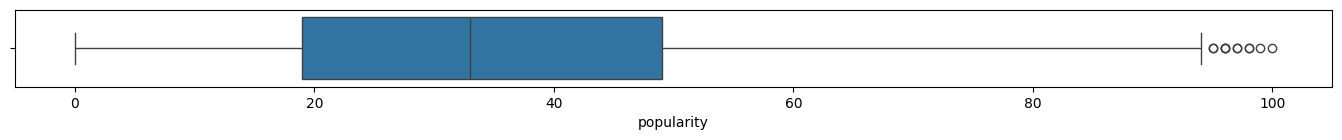

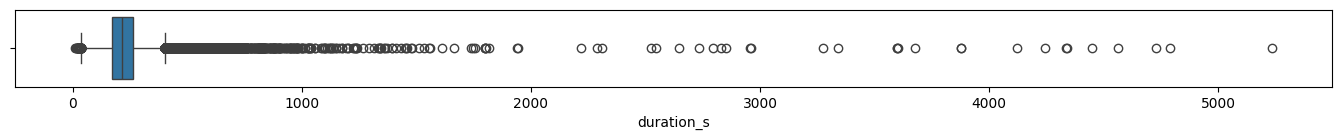

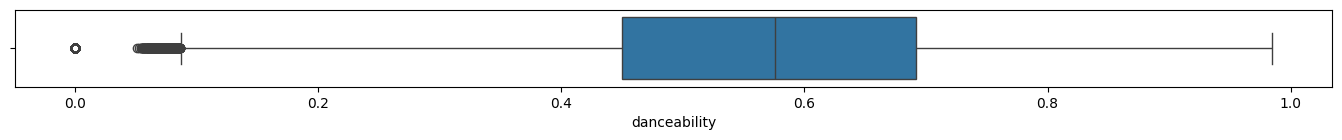

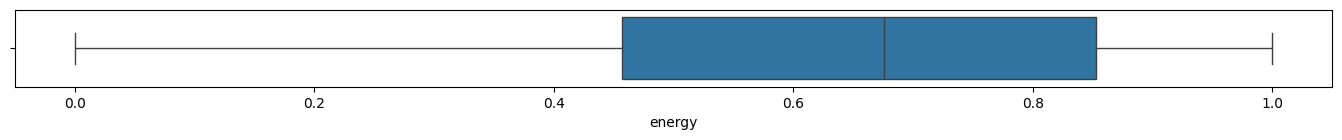

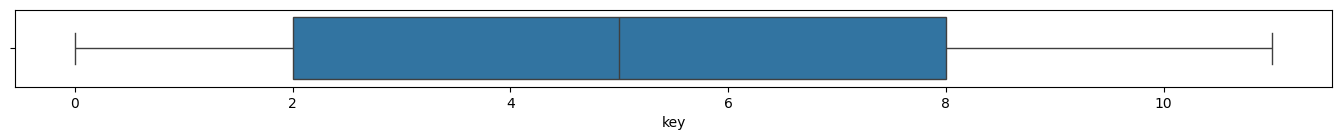

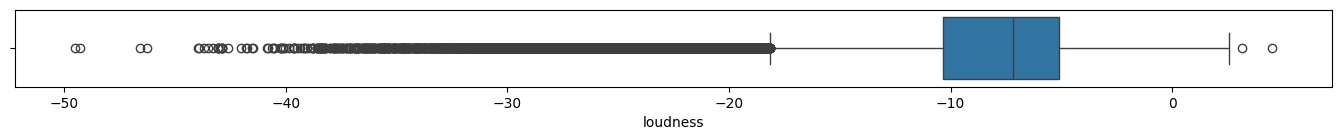

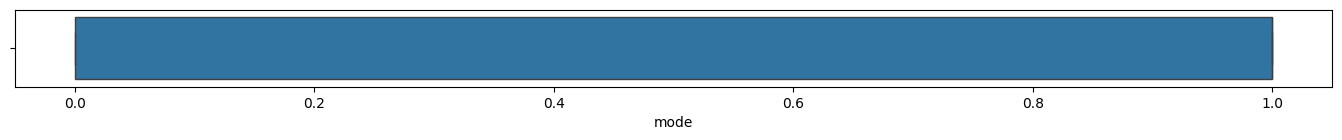

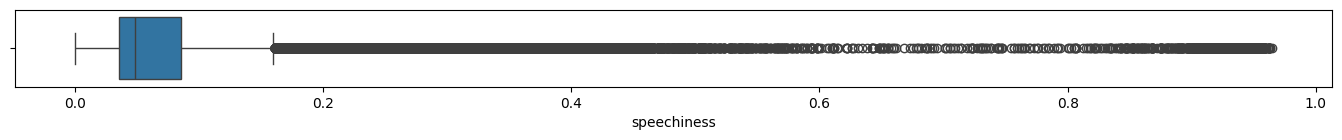

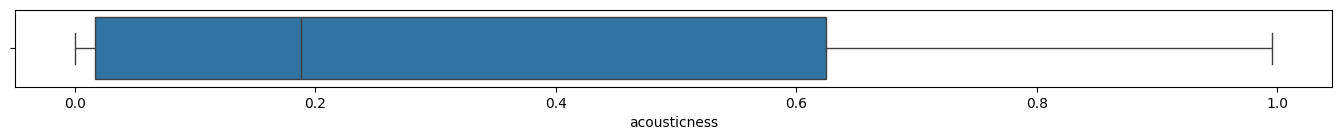

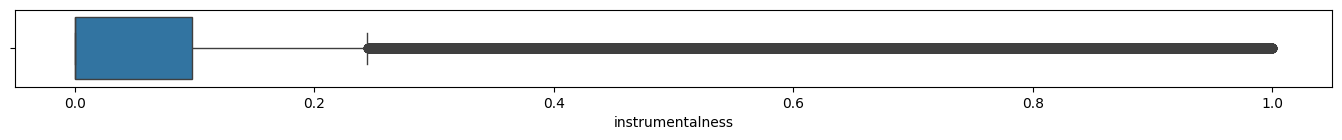

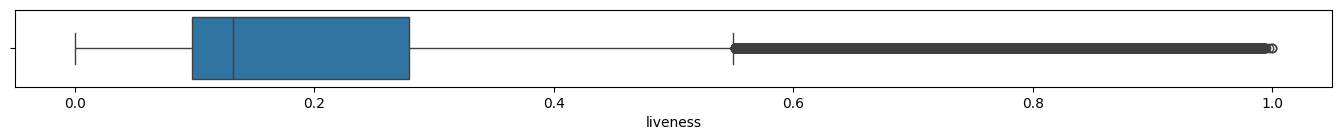

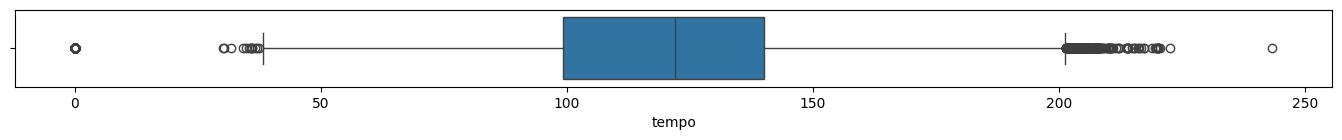

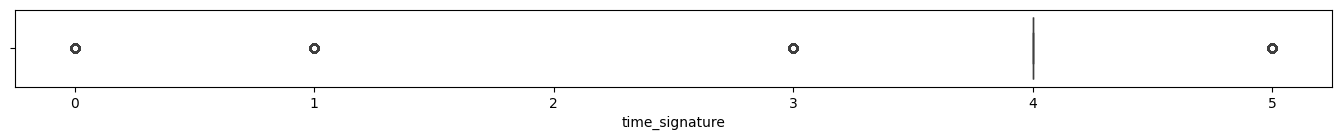

In [ ]:
#Comprobación de outliers
for col in variables_cuantitativas:
    plt.figure(figsize = (17,1))
    sns.boxplot(data=df[variables_cuantitativas], x = col)
    #Este ciclo for nos permite visualisar las columnas numéricas con su visualización bajo boxplot para ver la presencia de outliers dentro de nuestros datos



El gráfico de bloxplot nos permite ver la cantidad de valores outliers y distribuciones de cada variable, cada uno con su respectiva escala.
Cajas como danceability y energy se encuentran inclinados hacia la derecha, debido a que la mayoría de canciones están hechas para ser dinámicas y rítmicas.


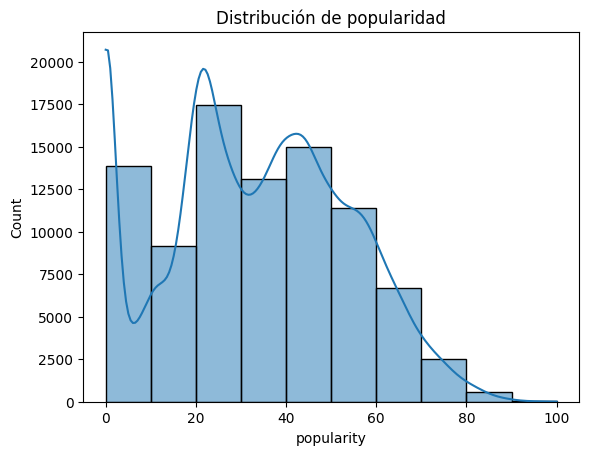

In [ ]:
# Gráfico de histograma con líneas para distribución de popularidad
sns.histplot(data=df, x="popularity", bins=10, kde=True)
plt.title("Distribución de popularidad")
plt.show()

Se presencia una distribución hacia la izquierda con una acumulación masiva de canciones con popularidad 0, dándonos a entender que en la totalidad de las canciones la mayoría presenta un rango de popularidad de [0-50], mientras que hay un número reducido de canciones con un umbral de popularidad del [51-100], desde ahí va en declive.
El gráfico al no comportarse como una campana de Gauss perfecta, teniendo en sí, múltiples jorobas, dejando en criterio que las canciones no se comportan de forma normal o predecible.

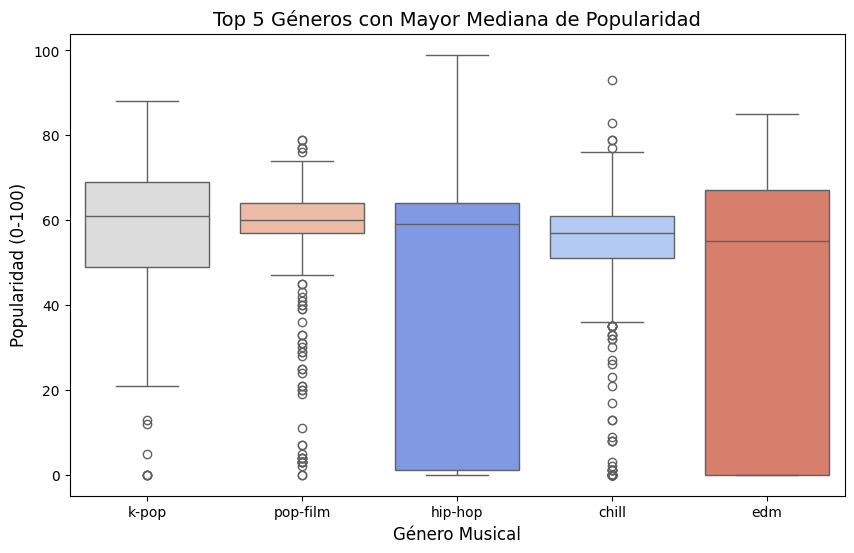

In [ ]:
# 1. Identificar los 5 géneros con la mayor mediana de popularidad
top_5_generos = df.groupby('track_genre')['popularity'].median().nlargest(5).index

# 2. Filtrar el dataset para conservar solo las filas de esos 5 géneros
df_top5 = df[df['track_genre'].isin(top_5_generos)]

# 3. Generar el gráfico corregido
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_top5,
    x='track_genre',
    y='popularity',
    hue='track_genre',     # Asigna la variable categórica a hue
    order=top_5_generos,
    palette='coolwarm',
    legend=False           # Oculta la leyenda redundante
)

# 4. Ajustes estéticos para la presentación
plt.title('Top 5 Géneros con Mayor Mediana de Popularidad', fontsize=14)
plt.xlabel('Género Musical', fontsize=12)
plt.ylabel('Popularidad (0-100)', fontsize=12)
plt.show()

Géneros como el pop y hip-hop presentan rangos intercuartiles más largos a comparación de los otros, estos abarcan desde el éxito total hasta el fracaso absoluto, significando que invertir en estos conlleva una apuesta de alto riesgo ya que no garantizan popularidad.
El k-pop y pop-film presentan cajas compactas teniendo una mediana alta y dispersión baja dando segurar como mercado seguro y estable.
A pesar de la estabilidad de pop-film, chill o k-pop se hace presencia de gran cantidad de outliers cercanos a una popularidad baja, concientizando que el género no basta por si solo para medir la popularidad y se necesitan de otras variables.

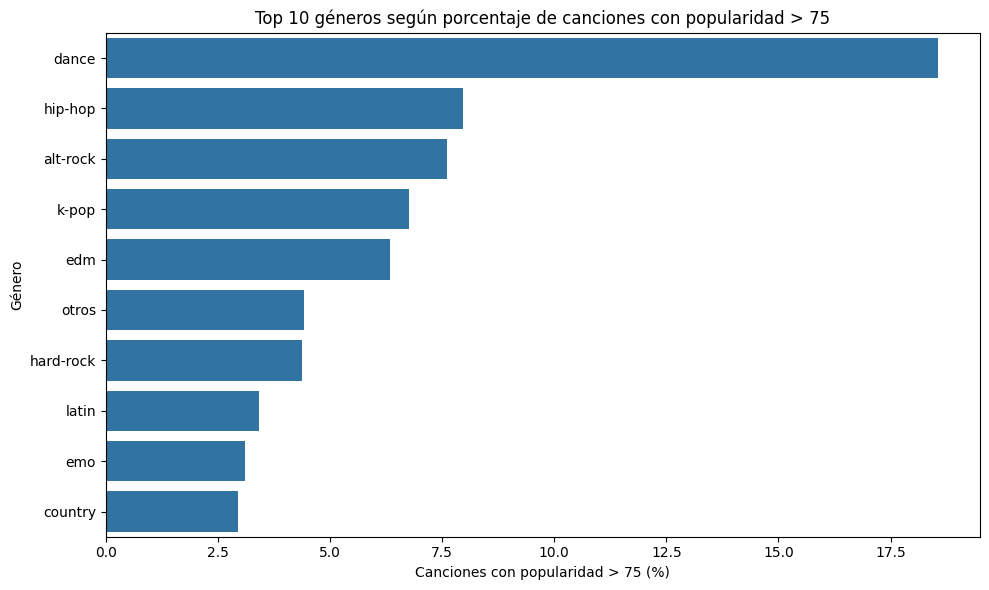

In [ ]:
#Variable para aislar canciones que superen el umbral de 75 de popularidad
df['hit_popular'] = df['popularity'] > 75 #Variable auxiliar
#Agregación y filtrado estadístico
hit_rate_genero = (
    df.groupby('track_genre')
      .agg(
          cantidad_canciones=('track_id', 'count'),#Volumen total de género
          porcentaje_hits=('hit_popular', 'mean')#Tasa de conversión a "hit"
      )
      #Se exluyen géneros con menos de 200 canciones
      .query('cantidad_canciones >= 200')
      #Transformamos la proporción (0-1) a porcentaje (0-100)
      .assign(porcentaje_hits=lambda x: x['porcentaje_hits'] * 100)
      #Se ordena de mayor a menor
      .sort_values('porcentaje_hits', ascending=False)
      .reset_index()
)
#Variable con el Top 10
top_generos = hit_rate_genero.head(10)
#Configuracion visual
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_generos,
    x='porcentaje_hits',
    y='track_genre'
)

plt.title('Top 10 géneros según porcentaje de canciones con popularidad > 75')
plt.xlabel('Canciones con popularidad > 75 (%)')
plt.ylabel('Género')

plt.tight_layout()
plt.show()

Se observa una mayor proporción de canciones pop y dance como exitosas, lo que puede indicar una predilección del público a música más orientada al baile más que a la complejidad musical.


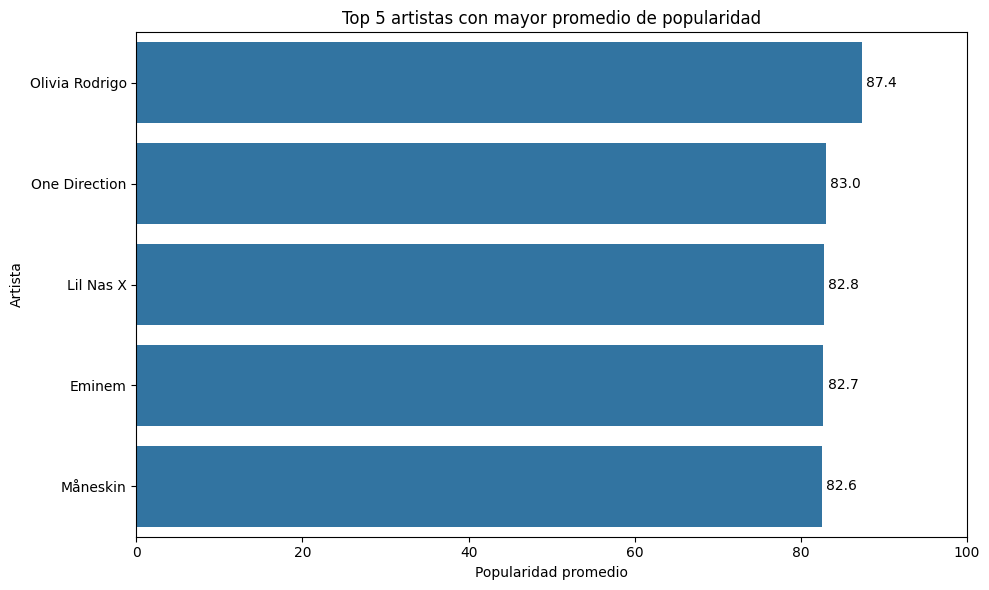

In [ ]:
#Gráfico de barras para los 5 artistas con mayor popularidad promedio
# Calcular cantidad de canciones y popularidad promedio por artista
artistas = (
    df.groupby('artista_principal')
      .agg(
          promedio_popularidad=('popularity', 'mean'),
          cantidad_canciones=('track_id', 'count')
      )
      .query('cantidad_canciones >= 5')
      .sort_values('promedio_popularidad', ascending=False)
      .head(5)
      .reset_index()
)
# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(
    data=artistas,
    x='promedio_popularidad',
    y='artista_principal'
)
plt.title('Top 5 artistas con mayor promedio de popularidad')
plt.xlabel('Popularidad promedio')
plt.ylabel('Artista')
plt.xlim(0, 100)
# Mostrar valor sobre cada barra
for i, valor in enumerate(artistas['promedio_popularidad']):
    plt.text(
        valor + 0.5,
        i,
        f'{valor:.1f}',
        va='center'
    )
plt.tight_layout()
plt.show()

En el top 5, se encuentra Olivia Rodrigo liderando con 87.4 como la artista con mayor promedio de popularidad, siguiendo The Kid LAROI con 85.2 y Chris Brown con 84.0, demostrando cifras competitivas en una escala del 0 al 100.
Esto asegura que el artista contiene un peso considerable en las reproducciones, independiente de otras variables.
Considerando la poca escala de éxito dentro del dataset, los artistas mencionados representan los outliers de éxito extremo.


In [ ]:
# Recupera la versión original de los datos
data_4 = df.copy()
# Obtiene las columnas a codificar
categorical_features = data_4.describe(include = ['object']).columns
# Calcula el promedio de la variable objetivo (calidad) por cada columna
for feature in categorical_features:
  mean_encoded = data_4.groupby(feature)['popularity'].mean()

  # Asigna este promedio a la columna codificada en el DataFrame
  data_4[f'{feature}_codificado'] = data_4[feature].map(mean_encoded)

data_4.head()


,track_id,artists,album_name,track_name,popularity,duration_s,explicit,danceability,energy,key,...,artista_principal,es_colaboracion,popularity_cat,hit_popular,track_id_codificado,artists_codificado,album_name_codificado,track_name_codificado,track_genre_codificado,artista_principal_codificado
0,0000vdREvCVMxbQTkS888c,Rill,Lolly,Lolly,44,160.725,True,0.910,0.374,8,...,Rill,0,"(40.0, 52.0]",False,44.0,44.000000,44.000000,44.0,32.348837,44.000000
1,000CC8EParg64OmTxVnZ0p,Glee Cast,Glee Love Songs,It's All Coming Back To Me Now (Glee Cast Vers...,47,322.933,False,0.269,0.516,0,...,Glee Cast,0,"(40.0, 52.0]",False,47.0,38.841727,43.777778,37.0,33.354125,39.858824
2,000Iz0K615UepwSJ5z2RE5,Paul Kalkbrenner;Pig&Dan,X,Böxig Leise - Pig & Dan Remix,22,515.360,False,0.686,0.560,5,...,Paul Kalkbrenner,1,"(15.0, 26.0]",False,22.0,22.000000,30.375000,22.0,33.283616,32.193548
3,000RDCYioLteXcutOjeweY,Jordan Sandhu,Teeje Week,Teeje Week,62,190.203,False,0.679,0.770,0,...,Jordan Sandhu,0,"(52.0, 100.0]",False,62.0,61.166667,62.000000,62.0,42.429929,60.555556
4,000qpdoc97IMTBvF8gwcpy,Paul Kalkbrenner,Zeit,Tief,19,331.240,False,0.519,0.431,6,...,Paul Kalkbrenner,0,"(15.0, 26.0]",False,19.0,34.260870,53.647059,19.0,33.283616,32.193548


In [ ]:
#verificar datos
df.head()

,track_id,artists,album_name,track_name,popularity,duration_s,explicit,danceability,energy,key,...,liveness,valence,tempo,time_signature,track_genre,valence_instrumentalness_sum,artista_principal,es_colaboracion,popularity_cat,hit_popular
0,0000vdREvCVMxbQTkS888c,Rill,Lolly,Lolly,44,160.725,True,0.910,0.374,8,...,0.1540,0.432,104.042,4,german,0.43501,Rill,0,"(40.0, 52.0]",False
1,000CC8EParg64OmTxVnZ0p,Glee Cast,Glee Love Songs,It's All Coming Back To Me Now (Glee Cast Vers...,47,322.933,False,0.269,0.516,0,...,0.1170,0.341,178.174,4,club,0.34100,Glee Cast,0,"(40.0, 52.0]",False
2,000Iz0K615UepwSJ5z2RE5,Paul Kalkbrenner;Pig&Dan,X,Böxig Leise - Pig & Dan Remix,22,515.360,False,0.686,0.560,5,...,0.1110,0.108,119.997,4,minimal-techno,0.28900,Paul Kalkbrenner,1,"(15.0, 26.0]",False
3,000RDCYioLteXcutOjeweY,Jordan Sandhu,Teeje Week,Teeje Week,62,190.203,False,0.679,0.770,0,...,0.0825,0.839,161.721,4,hip-hop,0.83900,Jordan Sandhu,0,"(52.0, 100.0]",False
4,000qpdoc97IMTBvF8gwcpy,Paul Kalkbrenner,Zeit,Tief,19,331.240,False,0.519,0.431,6,...,0.0916,0.234,129.971,4,minimal-techno,0.95400,Paul Kalkbrenner,0,"(15.0, 26.0]",False


In [ ]:
#verificar datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89740 entries, 0 to 89739
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   track_id                      89740 non-null  object  
 1   artists                       89740 non-null  object  
 2   album_name                    89740 non-null  object  
 3   track_name                    89740 non-null  object  
 4   popularity                    89740 non-null  int64   
 5   duration_s                    89740 non-null  float64 
 6   explicit                      89740 non-null  bool    
 7   danceability                  89740 non-null  float64 
 8   energy                        89740 non-null  float64 
 9   key                           89740 non-null  int64   
 10  loudness                      89740 non-null  float64 
 11  mode                          89740 non-null  int64   
 12  speechiness                   89740 non-null  

#Preprocesamiento

In [ ]:
df.drop(columns=['popularity', 'popularity_cat']).head()

,track_id,artists,album_name,track_name,duration_s,explicit,danceability,energy,key,loudness,...,instrumentalness,liveness,valence,tempo,time_signature,track_genre,valence_instrumentalness_sum,artista_principal,es_colaboracion,hit_popular
0,0000vdREvCVMxbQTkS888c,Rill,Lolly,Lolly,160.725,True,0.910,0.374,8,-9.844,...,0.00301,0.1540,0.432,104.042,4,german,0.43501,Rill,0,False
1,000CC8EParg64OmTxVnZ0p,Glee Cast,Glee Love Songs,It's All Coming Back To Me Now (Glee Cast Vers...,322.933,False,0.269,0.516,0,-7.361,...,0.00000,0.1170,0.341,178.174,4,club,0.34100,Glee Cast,0,False
2,000Iz0K615UepwSJ5z2RE5,Paul Kalkbrenner;Pig&Dan,X,Böxig Leise - Pig & Dan Remix,515.360,False,0.686,0.560,5,-13.264,...,0.18100,0.1110,0.108,119.997,4,minimal-techno,0.28900,Paul Kalkbrenner,1,False
3,000RDCYioLteXcutOjeweY,Jordan Sandhu,Teeje Week,Teeje Week,190.203,False,0.679,0.770,0,-3.537,...,0.00000,0.0825,0.839,161.721,4,hip-hop,0.83900,Jordan Sandhu,0,False
4,000qpdoc97IMTBvF8gwcpy,Paul Kalkbrenner,Zeit,Tief,331.240,False,0.519,0.431,6,-13.606,...,0.72000,0.0916,0.234,129.971,4,minimal-techno,0.95400,Paul Kalkbrenner,0,False


In [ ]:
df.duration_s.max()

5237.295

In [ ]:
#Variable objetivo 'popularity'
X = df[['speechiness', 'valence_instrumentalness_sum', 'es_colaboracion', 'track_genre', 'artista_principal']]
y = df['popularity']

# Separación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Justificación de Selección y Descarte de Variables

La selección final de características responde a los hallazgos estadísticos del Análisis Exploratorio de Datos (EDA) y a la necesidad de entregar predictores con señal real, evitando introducir ruido o sobreajuste (*overfitting*) en el modelo.

---

### 1. Variables Seleccionadas para el Modelo

* **`artista_principal` (Target Encoding):**
  * Presenta una asociación categórica sobresaliente con la popularidad (V de Cramér de ≈ 0.7834).
  * El peso comercial del artista es el factor individual con mayor poder explicativo del éxito de una canción. Se aplica *Target Encoding* para capturar este impacto reduciendo el riesgo de dispersión por alta cardinalidad.
* **`track_genre` (One-Hot Encoding):**
  * Muestra una asociación estadística significativa frente al target (V de Cramér de ≈ 0.5433).
  * El género musical define en gran medida la visibilidad comercial y el comportamiento de la audiencia en plataformas de streaming.
* **`valence_instrumentalness_sum` (Numérica continua):**
  * Variable creada mediante ingeniería de características al sumar valencia e instrumentalidad.
  * Mientras que de forma individual presentaban correlaciones marginales, su combinación aditiva eleva la asociación lineal conjunta a un ≈ 12% (|r| ≈ 0.12), convirtiéndose en la interacción acústica con mayor señal predictiva.
* **`es_colaboracion` (Numérica / Binaria):**
  * Registra una asociación moderada con la popularidad (V de Cramér de ≈ 0.1180).
  * Captura el fenómeno comercial de los lanzamientos conjuntos (*feats*), los cuales suelen traccionar mayor base de oyentes y visibilidad en playlists.
* **`speechiness` (Numérica continua):**
  * Es la variable acústica cruda con mayor magnitud de correlación negativa frente al target (r ≈ -0.0681).
  * Se conserva deliberadamente dentro del grupo numérico para permitir que algoritmos futuros puedan identificar posibles patrones no lineales vinculados a pistas con mayor contenido hablado o vocal.

---

### 2. Justificación de Variables Descartadas

* **Identificadores y textos de alta cardinalidad (`track_id`, `track_name`, `album_name`, `artists` original):**
  * Aunque arrojan valores de V de Cramér artificialmente elevados (entre 0.83 y 0.94), esto responde a un artefacto matemático debido a que casi cada fila tiene un valor distinto.
  * Mantener estas variables provocaría memorización espuria (*overfitting*) y fuga de datos en lugar de aprendizaje generalizable.
* **Variables acústicas numéricas crudas (`energy`, `loudness`, `danceability`, `tempo`, `acousticness`, `liveness`, `key`, `mode`, `time_signature`):**
  * Presentan coeficientes de correlación lineal extremadamente débiles frente a la popularidad (todos en el rango de -0.04 a +0.03), explicando individualmente menos del 1% o 1.5% de la varianza del objetivo.
  * Incluirlas de forma directa solo aportaría ruido innecesario y dimensionalidad residual a los estimadores.
* **`valence` e `instrumentalness` en su formato individual:**
  * Se descartaron de forma aislada porque su información predictiva fue absorbida y potenciada en la característica combinada `valence_instrumentalness_sum`.

In [ ]:
#Enrutamiento de Características
cols_num = ['speechiness', 'valence_instrumentalness_sum', 'es_colaboracion']
cols_nom_ohe = ['track_genre']
cols_nom_te = ['artista_principal']

In [ ]:
#Ensamblaje del Preprocesador
preprocesador = ColumnTransformer(
    transformers=[
        ("num", 'passthrough', cols_num),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cols_nom_ohe),
        ("te", TargetEncoder(), cols_nom_te)
    ],
    remainder='drop',
    verbose_feature_names_out=False
).set_output(transform="pandas")

X_train_procesado = preprocesador.fit_transform(X_train, y_train)
X_test_procesado = preprocesador.transform(X_test)